# Bootcamp Python - PY4
## Modulo 2: Machine Learning Avanzado y Feature Engineering
### Sesion 3 (Semana 7): DBSCAN, Comparacion de Modelos y Perfilamiento de Clusters

Segmentacion de perfiles basada en algoritmos no supervisados.

---

### Que hicimos en las sesiones anteriores

- Sesion 1: exploramos el dataset `CC_GENERAL` y construimos un Pipeline de preprocesamiento
  (`SimpleImputer` + `StandardScaler`).
- Sesion 2: aplicamos PCA para visualizar los datos en 2D y entrenamos K-Means, justificando K
  con el Metodo del Codo y el Coeficiente de Silueta. Integramos todo en un pipeline.

### Que vamos a hacer hoy

1. Entrenar un segundo algoritmo de clustering: **DBSCAN**.
2. Comparar DBSCAN contra K-Means (el "duelo de algoritmos").
3. Elegir el mejor modelo y visualizar sus clusters.
4. Hacer el **perfilamiento** de al menos 2 clusters: describir con palabras que tipo de cliente
   representa cada grupo.

### Paso 0: Configuracion inicial y recapitulacion

Volvemos a cargar el dataset y reconstruir el pipeline de preprocesamiento y el PCA que armamos
en las sesiones anteriores, para que esta notebook se pueda ejecutar de forma independiente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

sns.set_style("white")
pd.set_option("display.max_columns", None)


In [2]:
BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/datasets/"

df = pd.read_csv(BASE_URL + "CC_GENERAL.csv")

features = df.drop(columns=["CUST_ID"])

pipeline_preprocesamiento = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

features_procesadas = pipeline_preprocesamiento.fit_transform(features)
df_procesado = pd.DataFrame(features_procesadas, columns=features.columns)

# PCA a 2 componentes, para visualizacion
pca_2d = PCA(n_components=2, random_state=42)
componentes_2d = pca_2d.fit_transform(df_procesado)
df_pca = pd.DataFrame(componentes_2d, columns=["PC1", "PC2"])

# Recreamos el K-Means final de la sesion 2
K_ELEGIDO = 4  # Debe coincidir con el valor que eligieron en la Sesion 2
modelo_kmeans_final = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
clusters_kmeans = modelo_kmeans_final.fit_predict(df_procesado)

df["cluster_kmeans"] = clusters_kmeans
df_pca["cluster_kmeans"] = clusters_kmeans

df_pca.head()


,PC1,PC2,cluster_kmeans
0,-1.683649,-1.072241,0
1,-1.134085,2.509150,2
2,0.969395,-0.383577,3
3,-0.888220,0.004648,0
4,-1.600021,-0.683795,0


### DBSCAN: intuicion del algoritmo

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) agrupa puntos segun **que
tan denso** es su vecindario, en vez de necesitar que le digamos cuantos clusters buscar. Dos
parametros son clave:

- `eps`: la distancia maxima entre dos puntos para considerarlos vecinos.
- `min_samples`: la cantidad minima de puntos que debe tener un vecindario (dentro del radio
  `eps`) para considerarse una zona densa.

Con esto, DBSCAN clasifica cada punto en una de tres categorias:

- **Punto core**: tiene al menos `min_samples` vecinos dentro de `eps`.
- **Punto borde (border)**: esta dentro del radio `eps` de un punto core, pero no tiene suficientes
  vecinos propios.
- **Punto de ruido (noise)**: no pertenece a ningun cluster. DBSCAN le asigna la etiqueta `-1`.

Esta es una diferencia enorme respecto a K-Means: DBSCAN **no obliga** a todos los puntos a
pertenecer a un cluster, y ademas **no necesitamos definir K de antemano**. A cambio, tenemos que
elegir bien `eps` y `min_samples`.  



--> Mira ese vídeo para hacerte una idea visual del DBSCAN algoritmo: https://www.youtube.com/watch?v=_A9Tq6mGtLI

### Paso 1: Elegir `eps` con el grafico de k-distancias

Una forma estandar de elegir `eps` es el **grafico de k-distancias**:

1. Para cada punto, calculamos la distancia a su k-esimo vecino mas cercano (usamos
   `k = min_samples`).
2. Ordenamos esas distancias de menor a mayor y las graficamos.
3. Buscamos el "codo" de la curva: ese valor de distancia es un buen candidato para `eps`.

La logica es parecida al Metodo del Codo que usamos con K-Means: buscamos el punto donde la
curva cambia de pendiente de forma brusca.

#### Sobre que datos entrenamos DBSCAN: 2 opciones

Antes de construir el grafico de k-distancias, hay que decidir sobre que datos vamos a
entrenar DBSCAN. Tenemos 2 opciones:

- **Opcion 1: sobre `df_procesado`** (el dataset completo, ya imputado y escalado, con las 17
  variables originales). Usa toda la informacion disponible, pero recuerda el problema que
  discutimos antes: en 17 dimensiones las distancias entre puntos tienden a "parecerse" mas
  entre si (maldicion de la dimensionalidad), lo que puede dejar mucho ruido.
- **Opcion 2: sobre `df_pca`** (las 2 componentes principales que ya calculamos). Al trabajar en
  solo 2 dimensiones, DBSCAN suele encontrar zonas densas con mayor claridad y dejar menos
  ruido. La contrapartida es que estamos clusterizando sobre una version resumida (y con algo de
  perdida de informacion) de los datos originales.

Para no repetir el codigo dos veces, definimos una sola variable de control,
`USAR_PCA_PARA_DBSCAN`, que vamos a usar en el resto de esta seccion (tanto para el grafico de
k-distancias como para entrenar el modelo). Cambia su valor a `False` si quieres experimentar
entrenando DBSCAN directamente sobre `df_procesado`.

In [3]:
# Define la cantidad de vecinos que se considerarán para cada punto
MIN_SAMPLES = 10

# Opcion 1: False -> entrena DBSCAN sobre df_procesado (17 dimensiones)
# Opcion 2: True  -> entrena DBSCAN sobre df_pca (2 componentes principales)
USAR_PCA_PARA_DBSCAN = False

datos_dbscan = df_pca[["PC1", "PC2"]] if USAR_PCA_PARA_DBSCAN else df_procesado
print("Datos utilizados para DBSCAN:", "df_pca (2 dimensiones)" if USAR_PCA_PARA_DBSCAN else "df_procesado (17 dimensiones)")


Datos utilizados para DBSCAN: df_procesado (17 dimensiones)


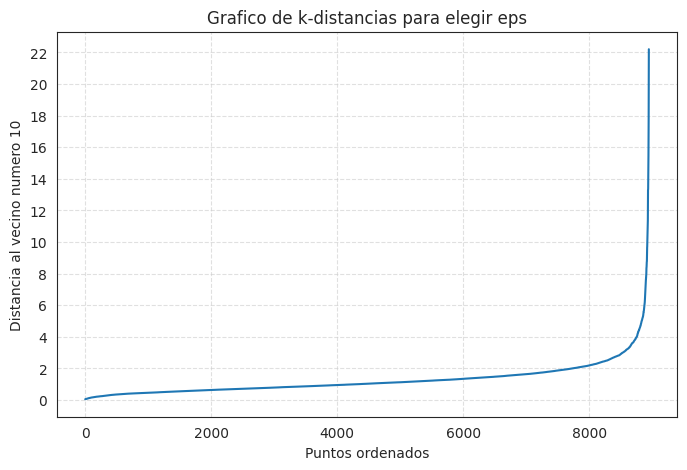

In [4]:
vecinos = NearestNeighbors(n_neighbors=MIN_SAMPLES)  # Crea el modelo para buscar los k vecinos más cercanos de cada observación
vecinos_ajustados = vecinos.fit(datos_dbscan)  # Entrena el modelo utilizando los datos elegidos (df_pca o df_procesado)
distancias, indices = vecinos_ajustados.kneighbors(datos_dbscan)  # Calcula las distancias y los índices de los k vecinos más cercanos para cada observación

# Nos quedamos con la distancia al vecino más lejano dentro de los k vecinos considerados (última columna, -1)
k_distancias = np.sort(distancias[:, -1])
# La columna -1 corresponde al k-ésimo vecino más cercano (en este caso, el décimo vecino), que es el más lejano de los 10 vecinos encontrados.
# Luego ordenamos esas distancias de menor a mayor para construir el gráfico k-distance y elegir un valor adecuado de eps.

plt.figure(figsize=(8, 5))
plt.plot(k_distancias)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al vecino numero {MIN_SAMPLES}")
plt.title("Grafico de k-distancias para elegir eps")

# mas precision de tick mark
plt.yticks(np.arange(0, k_distancias.max(), 2))
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


nota que la distancia no tiene unit, o podriamos decir: standardized Euclidean units

--> en que valor del eje Y ubican el "codo" de la curva? Tenemos que elegir la valora un poco antes del codo, para `eps`.

### Paso 2: Entrenar DBSCAN

Con un valor inicial de `eps` (tomado del grafico anterior) y el `min_samples` que ya definimos,
entrenamos DBSCAN. Recuerda que la etiqueta `-1` identifica los puntos de ruido.

In [5]:
EPS_ELEGIDO = 1.5 # Actualiza este valor segun el codo que identificaron en el grafico anterior

modelo_dbscan = DBSCAN(eps=EPS_ELEGIDO, min_samples=MIN_SAMPLES)  # Crea el modelo DBSCAN utilizando los valores de eps y min_samples definidos
clusters_dbscan = modelo_dbscan.fit_predict(datos_dbscan)  # Entrena el modelo sobre los datos elegidos en el paso anterior (df_pca o df_procesado), y asigna un clúster a cada observación; los puntos de ruido reciben la etiqueta -1

df["cluster_dbscan"] = clusters_dbscan  # Guarda la etiqueta de clúster obtenida para cada observación en el DataFrame original
df_pca["cluster_dbscan"] = clusters_dbscan  # Agrega las etiquetas de clúster al DataFrame con las componentes principales para facilitar su visualización

# Cuenta la cantidad de clústeres encontrados (sin incluir el ruido)
n_clusters_dbscan = len(np.unique(clusters_dbscan[clusters_dbscan != -1]))
# Cuenta la cantidad de observaciones clasificadas como ruido (-1)
n_ruido = np.sum(clusters_dbscan == -1)


# Cuenta la cantidad de observaciones en cada clúster de DBSCAN
resumen_clusters_dbscan = (
    df["cluster_dbscan"]
    .value_counts()
    .sort_index()
    .reset_index()
)
resumen_clusters_dbscan.columns = ["Cluster", "Cantidad de observaciones"]


print("Clusters encontrados por DBSCAN:", n_clusters_dbscan)
print("Puntos de ruido:", n_ruido, f"({round(100 * n_ruido / len(df), 1)}% del total)")
print()
print(resumen_clusters_dbscan)


Clusters encontrados por DBSCAN: 1
Puntos de ruido: 1561 (17.4% del total)

   Cluster  Cantidad de observaciones
0       -1                       1561
1        0                       7389


### Paso 3: Ajustar los parametros

Es muy probable que la primera combinacion de `eps` y `min_samples` no de un resultado util (por
ejemplo, un solo cluster gigante, o casi todos los puntos marcados como ruido). Este ajuste es
iterativo:

- Si hay **demasiado ruido**: prueba aumentar `eps` un poco.
- Si obtienes **un solo cluster**: prueba disminuir `eps`.
- Cambiar `min_samples` tambien afecta el resultado: valores mas altos exigen zonas mas densas
  para formar un cluster.

Vuelve a la celda anterior, ajusta `EPS_ELEGIDO` (y si quieres `MIN_SAMPLES` en el Paso 1), y
vuelve a ejecutar hasta llegar a un resultado razonable (idealmente entre 2 y 5 clusters, con un
porcentaje de ruido que tenga sentido para el negocio).

Con nuestro dataset van a notar que DBSCAN deja un porcentaje de ruido
bastante mas alto que lo que uno esperaria. Esto no es un error: con 17 features, este dataset
tiene muchas dimensiones, y en espacios de alta dimensionalidad las distancias entre puntos
tienden a "parecerse" mas entre si (el fenomeno se conoce como maldicion de la dimensionalidad).
Esto hace que a DBSCAN le cueste mas encontrar zonas densas que con pocas variables. Es un buen
punto para discutir en el duelo de algoritmos: no siempre el algoritmo mas sofisticado es el mas
adecuado para cada dataset.

### Paso 4: Visualizar los clusters de DBSCAN

Graficamos los clusters de DBSCAN sobre el mismo plano de componentes principales que usamos
para K-Means. Los puntos de ruido (`-1`) van a aparecer como una categoria mas en la leyenda.

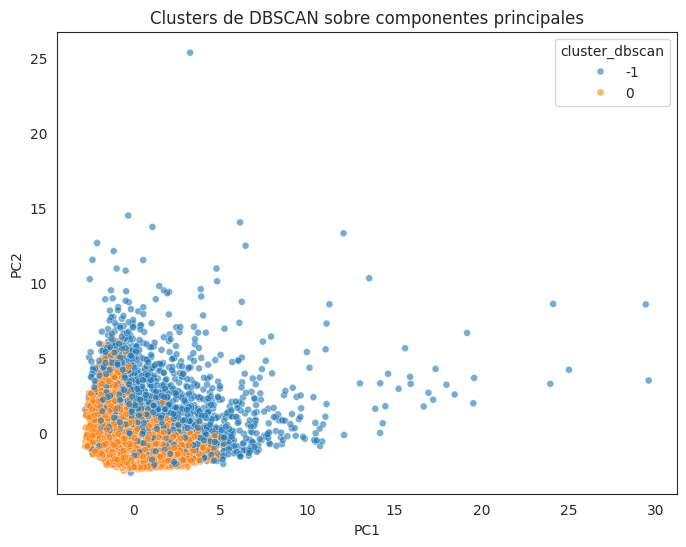

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster_dbscan",
    palette="tab10",
    alpha=0.6,
    s=25
)
plt.title("Clusters de DBSCAN sobre componentes principales")
plt.show()


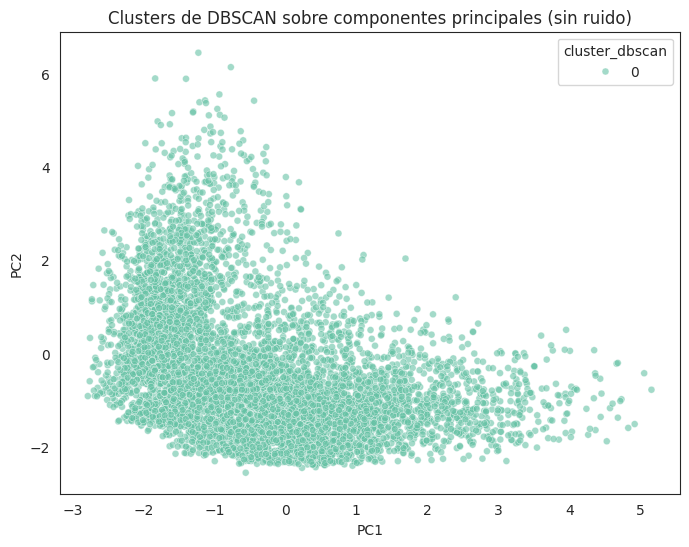

In [7]:
# Elimina las observaciones clasificadas como ruido (-1)
df_pca_sin_ruido = df_pca[df_pca["cluster_dbscan"] != -1]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_pca_sin_ruido,
    x="PC1",
    y="PC2",
    hue="cluster_dbscan",
    palette="Set2",
    alpha=0.6,
    s=25
)

plt.title("Clusters de DBSCAN sobre componentes principales (sin ruido)")
plt.show()

### Gaussian Mixture Model (GMM): un tercer enfoque

**Intuicion del algoritmo:** K-Means asume que los clusters son mas o menos esfericos y le asigna
a cada punto un unico cluster (asignacion "dura"). GMM en cambio asume que los datos fueron
generados por una mezcla de varias distribuciones normales (Gaussianas), cada una con su propio
centro y su propia forma (covarianza). Esto le permite:

- Modelar clusters con formas elipticas, no solo esfericas.
- Dar una **asignacion probabilistica** ("soft"): en vez de decir "este punto es del cluster 2",
  GMM puede decir "este punto tiene 70% de probabilidad de ser del cluster 2 y 30% de ser del
  cluster 0".

Para mantenerlo simple, vamos a usar el mismo numero de grupos que ya justificamos para K-Means
(`K_ELEGIDO`), para poder comparar resultados de forma mas directa.

--> Mira ese vídeo para hacerte una idea visual del GMM algoritmo: https://www.youtube.com/watch?v=wT2yLNUfyoM

In [16]:
from sklearn.mixture import GaussianMixture

N_COMPONENTES_GMM = K_ELEGIDO  # Usamos el mismo numero de grupos que en K-Means, para comparar mas facil

modelo_gmm = GaussianMixture(n_components=N_COMPONENTES_GMM, random_state=42)  # Crea el modelo GMM, especificando la cantidad de clusters a identificar
clusters_gmm = modelo_gmm.fit_predict(df_procesado)  # Entrena el modelo con los datos preprocesados y asigna a cada observación el componente gaussiano con mayor probabilidad de pertenencia

df["cluster_gmm"] = clusters_gmm  # Guarda la etiqueta de clúster en el DataFrame original

df_pca["cluster_gmm"] = clusters_gmm  # Agrega las etiquetas de clúster al DataFrame de PCA para facilitar su visualización

df["cluster_gmm"].value_counts().sort_index()  # cantidad de observaciones en cada clúster


,count
cluster_gmm,
0,1638
1,3733
2,832
3,2747


#### Visualizar los clusters de GMM

Graficamos los clusters de GMM sobre el mismo plano de componentes principales que usamos para
K-Means y DBSCAN.

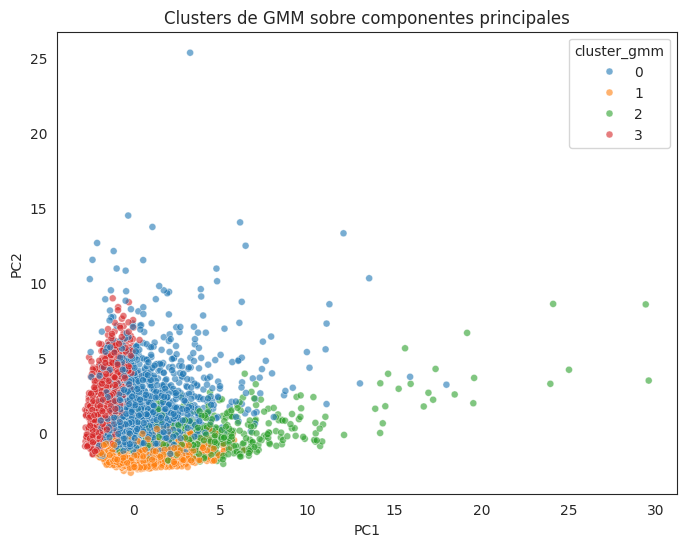

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster_gmm",
    palette="tab10",
    alpha=0.6,
    s=25
)
plt.title("Clusters de GMM sobre componentes principales")
plt.show()


#### Asignacion probabilistica

A diferencia de K-Means y DBSCAN, GMM puede darnos la probabilidad de que cada cliente
pertenezca a cada uno de los clusters, con `predict_proba`. Esto es util para identificar
clientes que estan "en la frontera" entre dos perfiles, en vez de forzarlos a pertenecer a uno
solo.

In [26]:
probabilidades_gmm = modelo_gmm.predict_proba(df_procesado)  # Calcula la probabilidad de que cada observación pertenezca a cada uno de los componentes gaussianos del modelo

columnas_prob = ['prob_cluster_0', 'prob_cluster_1', 'prob_cluster_2', 'prob_cluster_3'] # Genera los nombres de las columnas que almacenarán las probabilidades de pertenencia a cada clúster

df_probabilidades = pd.DataFrame(probabilidades_gmm, columns=columnas_prob).round(5)  # Convierte las probabilidades en un DataFrame
df_probabilidades.head(10)

,prob_cluster_0,prob_cluster_1,prob_cluster_2,prob_cluster_3
0,0.0,1.00000,0.0,0.00000
1,0.0,0.00000,0.0,1.00000
2,0.0,1.00000,0.0,0.00000
3,1.0,0.00000,0.0,0.00000
4,0.0,0.00149,0.0,0.99851
...,...,...,...,...
8945,0.0,1.00000,0.0,0.00000
8946,0.0,1.00000,0.0,0.00000
8947,0.0,1.00000,0.0,0.00000
8948,0.0,0.00000,0.0,1.00000


In [29]:
# Muestra los 10 clientes sobre los que el modelo GMM tiene menor nivel de confianza,
# lo que permite identificar observaciones que se encuentran cerca de la frontera entre dos o más clústeres.

df_probabilidades["prob_max"] = probabilidades_gmm.max(axis=1)  # Calcula, para cada observación (fila), la mayor probabilidad de pertenencia entre todos los clústeres.
df_probabilidades.sort_values("prob_max").head(10)  # Ordena las observaciones de MENOR a MAYOR según su probabilidad máxima de pertenencia.

# Las primeras filas corresponden a los clientes sobre los que el modelo tiene mayor incertidumbre, ya que presentan probabilidades más repartidas entre varios clústeres.

,prob_cluster_0,prob_cluster_1,prob_cluster_2,prob_cluster_3,prob_max
2814,0.00000,0.50160,0.00000,0.49840,0.501601
6999,0.50432,0.49568,0.00000,0.00000,0.504320
5029,0.00000,0.48968,0.00000,0.51032,0.510322
1968,0.00000,0.48642,0.51358,0.00000,0.513575
8194,0.00000,0.51402,0.00000,0.48598,0.514019
93,0.00000,0.51570,0.00000,0.48430,0.515696
630,0.00000,0.47454,0.52546,0.00000,0.525459
4552,0.00000,0.47366,0.52634,0.00000,0.526336
6176,0.00000,0.52837,0.47163,0.00000,0.528371
7579,0.00001,0.52859,0.47140,0.00000,0.528587


### Duelo de algoritmos: K-Means vs DBSCAN

Ya tenemos dos modelos entrenados. Para compararlos de forma objetiva, calculamos el
Coeficiente de Silueta de cada uno sobre los mismos datos preprocesados.  

El coeficiente de silueta se puede utilizar para comparar algoritmos de agrupamiento porque mide la calidad de los grupos producidos, independientemente del algoritmo específico utilizado.

Un detalle importante: el Coeficiente de Silueta no esta definido para puntos de ruido, asi que
para DBSCAN calculamos la metrica **excluyendo** los puntos con etiqueta `-1`. Ademas, si DBSCAN
encontro menos de 2 clusters reales, la metrica no se puede calcular.

Si tambien ejecutaste la seccion opcional de GMM, la incluimos en esta comparacion. Si no la ejecutaste, no hay problema: la celda de abajo detecta automaticamente si entrenaste GMM y solo lo compara si corresponde.

In [30]:
# Silhouette de K-Means (todos los puntos tienen clúster asignado)
silhouette_kmeans = silhouette_score(df_procesado, clusters_kmeans)

# Elimina los puntos de ruido de DBSCAN (-1)
df_dbscan_sin_ruido = df_procesado[clusters_dbscan != -1]
clusters_dbscan_sin_ruido = clusters_dbscan[clusters_dbscan != -1]

# Calcula Silhouette de DBSCAN solo si existen al menos 2 clústeres
silhouette_dbscan = silhouette_score(
    df_dbscan_sin_ruido,
    clusters_dbscan_sin_ruido
) if len(np.unique(clusters_dbscan_sin_ruido)) >= 2 else None

print("Silhouette Score - K-Means:", round(silhouette_kmeans, 3))
print("Silhouette Score - DBSCAN (sin ruido):", round(silhouette_dbscan, 3) if silhouette_dbscan is not None else None)

# La comparacion con GMM (solo si la hicimos)
if "clusters_gmm" in globals():
    silhouette_gmm = silhouette_score(df_procesado, clusters_gmm)
    print("Silhouette Score - GMM:", round(silhouette_gmm, 3))
else:
    print("GMM no fue entrenado en esta ejecucion (seccion opcional no ejecutada).")


Silhouette Score - K-Means: 0.198
Silhouette Score - DBSCAN (sin ruido): None
Silhouette Score - GMM: 0.104


Cual de los modelos obtuvo un mejor Coeficiente de
Silueta?   
Recuerda que un numero mas alto no siempre significa "mejor" en terminos de negocio: un
modelo que deja el 40% de los clientes como ruido puede tener buen silhouette y aun asi no ser
util para marketing. Con base en la metrica y en la visualizacion, decide cual de los dos modelos van a usar para el perfilamiento final.

### Paso 5: Definir el mejor modelo

Guardamos en una sola columna (`cluster_final`) la asignacion del modelo que eligieron como
mejor, para trabajar el resto de la notebook sobre esa columna unicamente.

Si entrenaste GMM, tambien lo puedes elegir como modelo final. Si no lo entrenaste, simplemente deja `MODELO_ELEGIDO` en `"kmeans"` o `"dbscan"`: el codigo de abajo funciona igual en ambos casos.

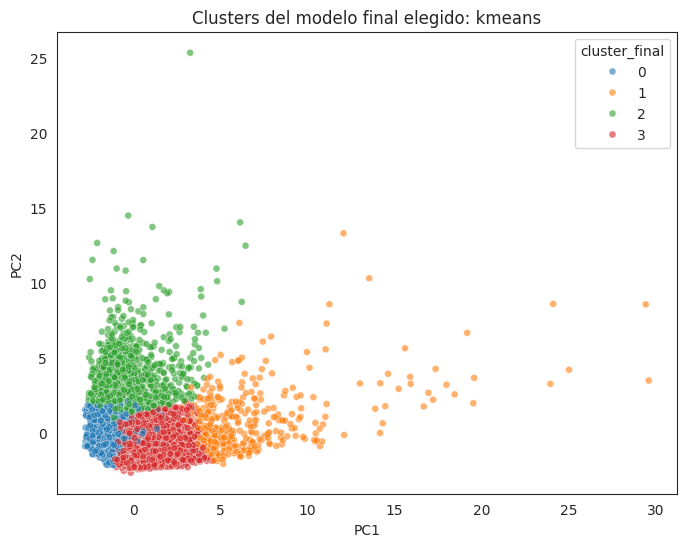

In [31]:
# Cambia este valor a "kmeans", "dbscan" o "gmm" segun lo que hayan decidido
# (usa "gmm" solo si ejecutaste la seccion opcional de Gaussian Mixture Model)
MODELO_ELEGIDO = "kmeans"

if MODELO_ELEGIDO == "kmeans":
    df["cluster_final"] = df["cluster_kmeans"]
    df_pca["cluster_final"] = df_pca["cluster_kmeans"]
elif MODELO_ELEGIDO == "dbscan":
    df["cluster_final"] = df["cluster_dbscan"]
    df_pca["cluster_final"] = df_pca["cluster_dbscan"]
elif MODELO_ELEGIDO == "gmm":
    df["cluster_final"] = df["cluster_gmm"]
    df_pca["cluster_final"] = df_pca["cluster_gmm"]
else:
    raise ValueError('MODELO_ELEGIDO debe ser "kmeans", "dbscan" o "gmm"')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster_final",
    palette="tab10",
    alpha=0.6,
    s=25
)
plt.title(f"Clusters del modelo final elegido: {MODELO_ELEGIDO}")
plt.show()


### Paso 6: Perfilamiento de clusters (insight final)

Este es el paso mas importante para el equipo de marketing. Un cluster sin interpretacion no
sirve de nada: necesitamos traducir numeros en un perfil de cliente entendible.

Vamos a calcular el promedio de las variables originales (sin escalar, para que sean faciles de
leer) para cada cluster. Esto nos va a permitir comparar, por ejemplo, que cluster tiene el
`BALANCE` mas alto, cual hace mas `CASH_ADVANCE`, cual paga mejor (`PRC_FULL_PAYMENT`), etc.

In [38]:
columnas_perfil = [ # Define las variables que se utilizarán para analizar el perfil promedio de cada clúster de clientes
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS",
    "PRC_FULL_PAYMENT", "TENURE"
]

perfil_clusters = df.groupby("cluster_final")[columnas_perfil].mean().round(1)  # Agrupa los clientes por clúster y calcula el valor promedio de cada variable seleccionada
perfil_clusters["n_clientes"] = df.groupby("cluster_final").size()  # Agrega la cantidad de clientes pertenecientes a cada clúster

perfil_clusters


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,n_clientes
cluster_final,,,,,,,,,,,
0,1012.7,270.0,209.9,60.4,596.5,3278.7,974.3,569.0,0.1,11.4,3977
1,3551.2,7681.6,5095.9,2587.2,653.6,9696.9,7288.7,1985.0,0.3,12.0,409
2,4602.4,501.9,320.2,181.8,4521.5,7546.2,3484.1,2020.8,0.0,11.4,1197
3,894.9,1236.2,594.0,642.5,210.6,4213.2,1332.2,646.0,0.3,11.6,3367


### Paso 7: Visualizacion de apoyo para el perfilamiento

Un heatmap normalizado (cada columna escalada entre 0 y 1) ayuda a comparar visualmente los
clusters entre si, sin que las variables con valores mas grandes (como `BALANCE`) dominen la
lectura visual.

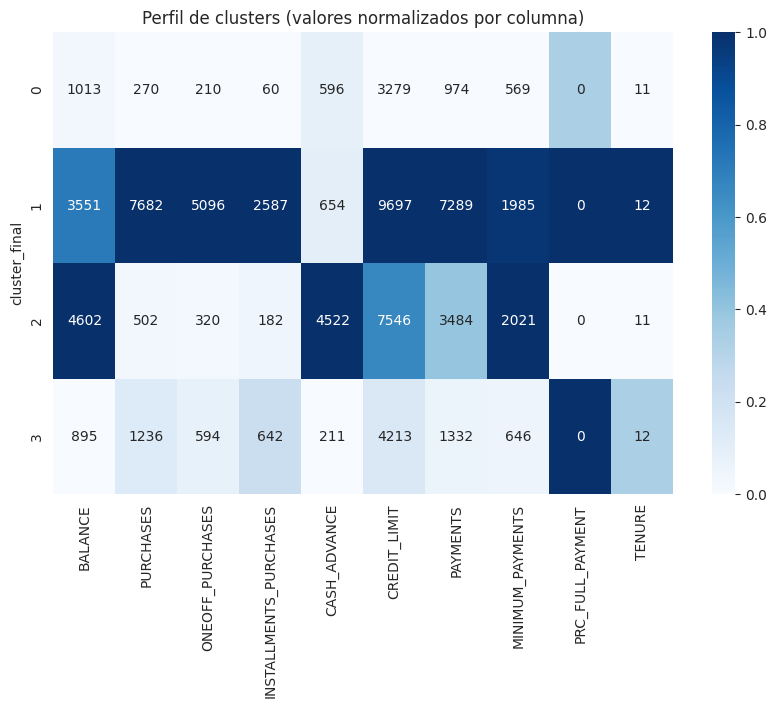

In [ ]:
# Normaliza cada variable entre 0 y 1 para poder comparar visualmente las diferencias relativas entre clústeres, independientemente de sus escalas originales
perfil_normalizado = (perfil_clusters[columnas_perfil] - perfil_clusters[columnas_perfil].min()) /  (perfil_clusters[columnas_perfil].max() - perfil_clusters[columnas_perfil].min())

plt.figure(figsize=(10, 6))
sns.heatmap(perfil_normalizado, cmap="Blues", annot=perfil_clusters[columnas_perfil].values, fmt=".0f")
plt.title("Perfil de clusters (valores normalizados por columna)")
plt.show()


#### Radar Chart para interpretar los clusters

El gráfico de radar es una herramienta útil para entender la identidad y las características principales de cada clúster.

Al representar múltiples variables al mismo tiempo, permite comparar visualmente los perfiles de los grupos e identificar patrones de comportamiento.

Los valores están normalizados para facilitar la comparación entre variables con diferentes unidades de medida. Por lo tanto, el gráfico no representa valores absolutos, sino la posición relativa de cada clúster frente a los demás.

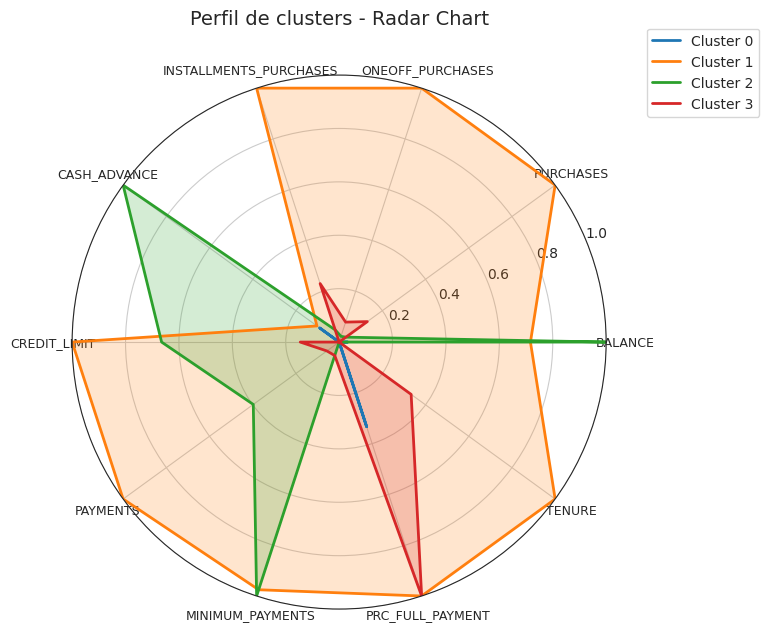

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Selecciona las variables utilizadas para describir el perfil de los clusters
features_radar = columnas_perfil

# Obtiene los valores promedio de cada variable por cluster
perfil_radar = perfil_clusters[features_radar]

# Normaliza cada variable entre 0 y 1 para que todas las dimensiones sean comparables
scaler = MinMaxScaler()

perfil_normalizado_radar = pd.DataFrame(
    scaler.fit_transform(perfil_radar),
    columns=perfil_radar.columns,
    index=perfil_radar.index
)

# Define las categorías del radar
categories = perfil_normalizado_radar.columns
N = len(categories)

# Calcula los ángulos de cada eje del radar
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
# Cierra el círculo agregando nuevamente el primer ángulo al final
angles += angles[:1]


fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))


for cluster, row in perfil_normalizado_radar.iterrows():
    values = row.tolist()
    values += values[:1]

    # Dibuja la línea del cluster
    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f"Cluster {cluster}"
    )

    # Rellena el área del cluster con transparencia
    ax.fill(
        angles,
        values,
        alpha=0.2
    )


ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 1)

ax.set_title(
    "Perfil de clusters - Radar Chart",
    fontsize=14,
    y=1.08
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1)
)

plt.tight_layout()
plt.show()

##### Interpretación de los perfiles de clientes obtenidos

Los clusters representan diferentes perfiles de comportamiento financiero de los clientes.
La interpretación se basa en las variables promedio observadas en cada grupo.

| Segmento de cliente | Características principales | Variables del dataset asociadas |
|---|---|---|
| **Clientes de alto valor / Premium** | Clientes con alto nivel de consumo, mayor capacidad crediticia y mayor interacción con la tarjeta. | `PURCHASES` ↑, `PAYMENTS` ↑, `CREDIT_LIMIT` ↑, `BALANCE` ↑, `PRC_FULL_PAYMENT` ↑ |
| **Compradores activos / Frequent shoppers** | Clientes que utilizan la tarjeta principalmente para realizar compras frecuentes, tanto de una sola cuota como en pagos diferidos. | `PURCHASES` ↑, `ONEOFF_PURCHASES` ↑, `INSTALLMENTS_PURCHASES` ↑, `TENURE` |
| **Usuarios de adelantos de efectivo / Cash advance users** | Clientes que utilizan la tarjeta principalmente como fuente de liquidez. Pueden presentar mayor dependencia del crédito y mayor riesgo financiero. | `CASH_ADVANCE` ↑, `BALANCE` ↑, `MINIMUM_PAYMENTS` ↑, `PRC_FULL_PAYMENT` ↓ |
| **Clientes inactivos / Bajo engagement** | Clientes con poca utilización de la tarjeta y baja actividad financiera. Representan una oportunidad de reactivación. | `PURCHASES` ↓, `ONEOFF_PURCHASES` ↓, `INSTALLMENTS_PURCHASES` ↓, `PAYMENTS` ↓, `CASH_ADVANCE` ↓ |

  


**Nota:** La numeración de los clusters (`Cluster 0`, `Cluster 1`, etc.) depende del algoritmo utilizado y no tiene un significado intrínseco. La asignación de nombres debe realizarse analizando los valores promedio de cada variable dentro de cada cluster.

  
    
    

<br><br>

## Comparación de algoritmos de clustering

| Algoritmo | Ventajas | Desventajas | ¿Cuándo utilizarlo? |
|------------|----------|-------------|----------------------|
| **K-Means** | • Simple y rápido.<br>• Fácil de interpretar.<br>• Escala bien a grandes volúmenes de datos.<br>• Produce clústeres compactos y bien definidos. | • Es necesario definir el número de clústeres (`k`).<br>• Sensible a valores atípicos (outliers).<br>• Funciona mejor con clústeres aproximadamente esféricos y de tamaño similar. | Cuando se conoce aproximadamente el número de grupos esperados y los datos presentan clústeres bien separados y de forma relativamente regular. Es una excelente opción para segmentación de clientes. |
| **DBSCAN** | • No requiere definir el número de clústeres.<br>• Detecta automáticamente observaciones de ruido (outliers).<br>• Puede encontrar clústeres de formas arbitrarias. | • Es sensible a la elección de `eps` y `min_samples`.<br>• Puede tener dificultades cuando los clústeres presentan densidades muy diferentes.<br>• Su desempeño disminuye en espacios de alta dimensionalidad. | Cuando se espera encontrar ruido o valores atípicos, o cuando los grupos no tienen una forma esférica. Es útil en datos geoespaciales, sensores o detección de anomalías. |
| **Gaussian Mixture Model (GMM)** | • Permite modelar clústeres elípticos y con diferentes tamaños.<br>• Asigna probabilidades de pertenencia a cada clúster (soft clustering).<br>• Es más flexible que K-Means. | • Es necesario definir el número de componentes.<br>• Es más lento que K-Means.<br>• Puede converger a soluciones locales y requiere mayor capacidad computacional. | Cuando los grupos presentan formas elípticas o existe incertidumbre en la pertenencia de algunas observaciones. Es útil cuando interesa conocer la probabilidad de pertenencia de cada individuo a los diferentes clústeres. |

### Resumen

- **K-Means:** la mejor opción cuando se buscan clústeres simples, bien separados y se conoce aproximadamente el número de grupos.
- **DBSCAN:** recomendado cuando existen valores atípicos o los clústeres tienen formas irregulares.
- **GMM:** adecuado cuando los clústeres pueden superponerse y se desea obtener probabilidades de pertenencia en lugar de asignaciones completamente rígidas.

<br><br>

### Cierre de la sesion y del proyecto

En estas tres sesiones completamos todo el flujo de trabajo de un proyecto de aprendizaje no
supervisado:

1. EDA y Pipeline de preprocesamiento (imputacion + escalado).
2. Reduccion de dimensionalidad con PCA para visualizar los datos.
3. Entrenamiento y validacion de K-Means (Metodo del Codo y Coeficiente de Silueta).
4. Entrenamiento y ajuste de DBSCAN (`eps` y `min_samples`), sobre el dataset completo o sobre las componentes principales.
5. Entrenamiento de un tercer modelo, Gaussian Mixture Model (GMM).
6. Comparacion de modelos y seleccion del mejor.
7. Perfilamiento de clusters, traduciendo numeros en perfiles de cliente accionables para
   marketing.
